In [2]:
library(eRm)
library(dplyr)
library(readxl)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
data <- read_excel("data_dea.xlsx")
head(data)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3,2,2,3,4,0,2,4,4,4,3
2,4,1,2,1,4,0,0,3,4,2,4
2,4,2,2,4,4,0,1,2,0,2,4
2,4,2,4,2,4,0,1,2,0,1,4
2,4,1,2,3,4,4,3,4,4,4,4
4,4,1,3,2,4,0,4,4,4,4,3


In [4]:
data[is.na(data)] <- 0

In [5]:
df_data <- as.data.frame(data)

# Membuat fungsi untuk merangkum distribusi per kolom
distribusi_soal <- lapply(df_data, function(x) table(factor(x, levels = 0:4)))

# Menampilkan hasil dalam bentuk tabel yang rapi
do.call(rbind, distribusi_soal)

,0,1,2,3,4
S1,8,8,11,50,25
S2,0,2,11,43,46
S3,1,38,35,16,12
S4,1,45,32,19,5
S5,0,35,23,30,14
S6,4,7,9,7,75
S7,48,2,19,13,20
S8,6,11,20,31,34
S9,4,4,26,27,41
S10,15,12,9,13,53


# UJI RASCH

In [6]:
# 2. Transformasi Data
# Aturan: 0&1 -> 0, 2 -> 1, 3 -> 2, 4 -> 3
# Fungsi recode akan mengolah data sesuai pemetaan yang kita tentukan
data0_3 <- data %>%
  mutate(across(everything(), ~ recode(., 
                                       `0` = 0, 
                                       `1` = 0, 
                                       `2` = 1, 
                                       `3` = 2, 
                                       `4` = 3)))

# 3. Cek kembali distribusi skor Anda untuk memastikan perubahannya berhasil
print("=== Distribusi Skor Setelah Collapsing ===")
print(table(as.matrix(data0_3)))

[1] "=== Distribusi Skor Setelah Collapsing ==="

  0   1   2   3 
296 232 283 413 


# UJI DATA 0-3

In [7]:
# 1. Pastikan objek data Anda adalah murni numerik (Matrix)
# Ini akan membuang semua atribut 'factor' atau label yang membingungkan R
data_matrix <- as.matrix(data0_3)
mode(data_matrix) <- "numeric"
head(data_matrix)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
0,2,1,1,2,3,0,1,3,3,3,2
1,3,0,1,0,3,0,0,2,3,1,3
1,3,1,1,3,3,0,0,1,0,1,3
1,3,1,3,1,3,0,0,1,0,0,3
1,3,0,1,2,3,3,2,3,3,3,3
3,3,0,2,1,3,0,3,3,3,3,2


In [8]:
# 3. Jalankan PCM menggunakan matriks yang sudah dipaksa numerik
rasch_model_poli <- PCM(data_matrix)

In [9]:
summary(rasch_model_poli)


Results of PCM estimation: 

Call:  PCM(X = data_matrix) 

Conditional log-likelihood: -1090.959 
Number of iterations: 40 
Number of parameters: 35 

Item (Category) Difficulty Parameters (eta): with 0.95 CI:
       Estimate Std. Error lower CI upper CI
S1.c2    -1.157      0.297   -1.740   -0.574
S1.c3    -0.194      0.346   -0.872    0.484
S2.c1    -1.912      0.745   -3.372   -0.451
S2.c2    -3.289      0.680   -4.622   -1.957
S2.c3    -3.174      0.660   -4.467   -1.880
S3.c1     0.160      0.236   -0.302    0.622
S3.c2     1.183      0.312    0.571    1.794
S3.c3     1.885      0.372    1.156    2.614
S4.c1     0.446      0.233   -0.011    0.904
S4.c2     1.242      0.292    0.669    1.815
S4.c3     3.023      0.496    2.051    3.995
S5.c1     0.433      0.270   -0.096    0.961
S5.c2     0.364      0.268   -0.161    0.889
S5.c3     1.500      0.355    0.804    2.197
S6.c1    -0.004      0.446   -0.878    0.871
S6.c2     0.222      0.482   -0.724    1.167
S6.c3    -1.995      0.3

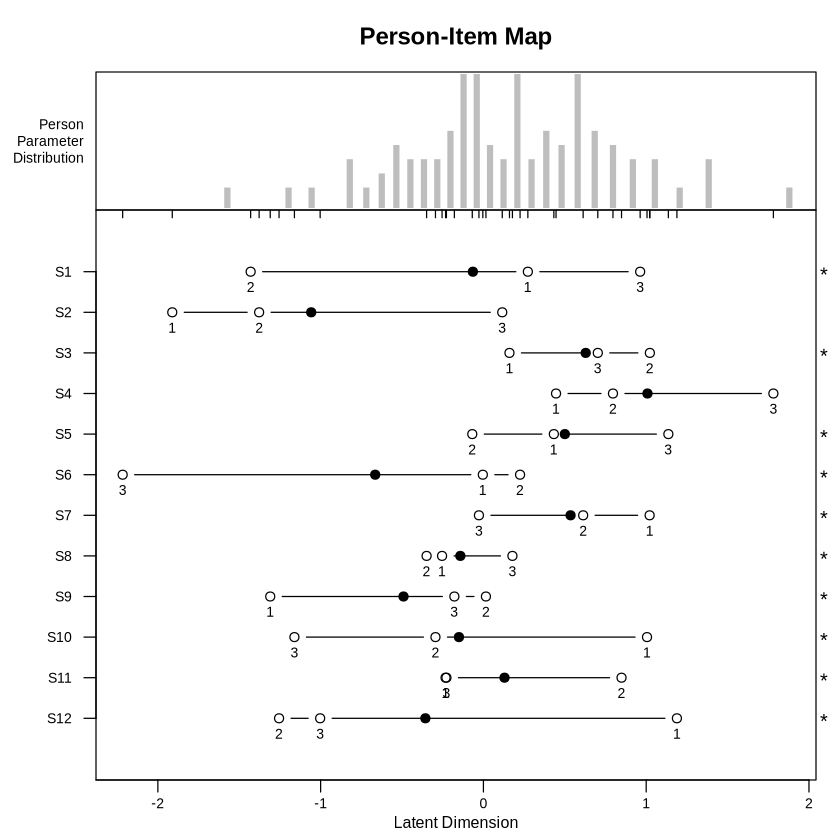

In [10]:
plotPImap(rasch_model_poli)

In [18]:
kemampuan_siswa <- person.parameter(rasch_model_poli)
summary(kemampuan_siswa)


Estimation of Ability Parameters

Collapsed log-likelihood: -326.5725 
Number of iterations: 11 
Number of parameters: 27 

ML estimated ability parameters (without spline interpolated values): 
              Estimate Std. Err.       2.5 %      97.5 %
theta P1    0.20856313 0.2932581 -0.36621213  0.78333838
theta P2   -0.12192050 0.2839767 -0.67850459  0.43466359
theta P3   -0.12192050 0.2839767 -0.67850459  0.43466359
theta P4   -0.20251474 0.2839733 -0.75909219  0.35406272
theta P5    0.79610716 0.3415950  0.12659326  1.46562107
theta P6    0.68386836 0.3289000  0.03923624  1.32850047
theta P7    0.57914572 0.3186669 -0.04542991  1.20372136
theta P8    0.20856313 0.2932581 -0.36621213  0.78333838
theta P9    1.38401678 0.4410333  0.51960734  2.24842621
theta P10  -0.04104491 0.2849520 -0.59954047  0.51745066
theta P11  -0.12192050 0.2839767 -0.67850459  0.43466359
theta P12  -0.04104491 0.2849520 -0.59954047  0.51745066
theta P13   0.79610716 0.3415950  0.12659326  1.46562107
theta 

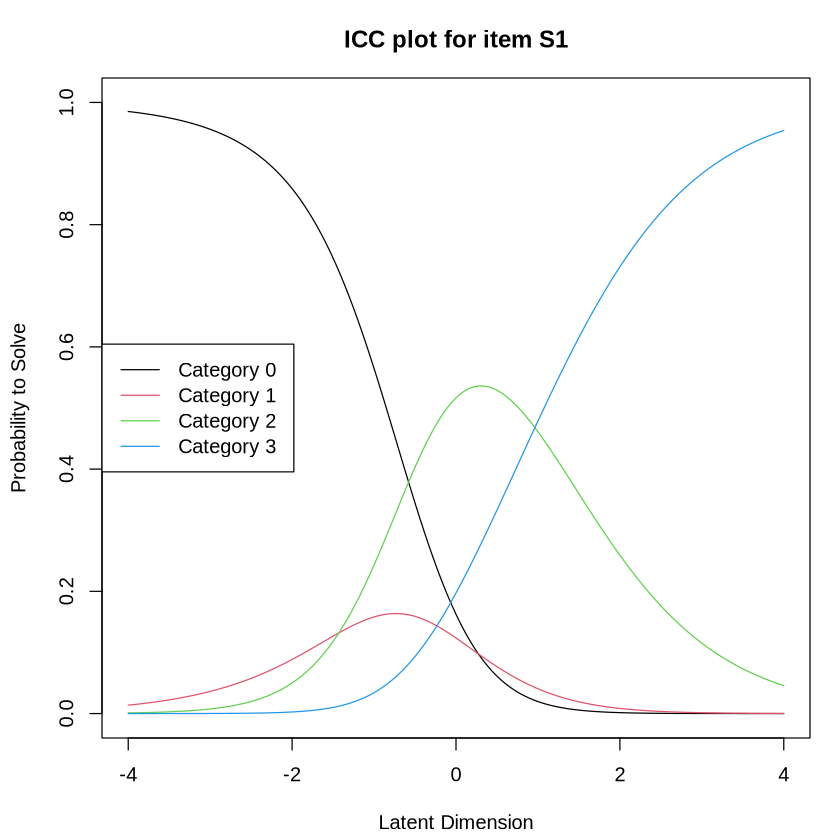

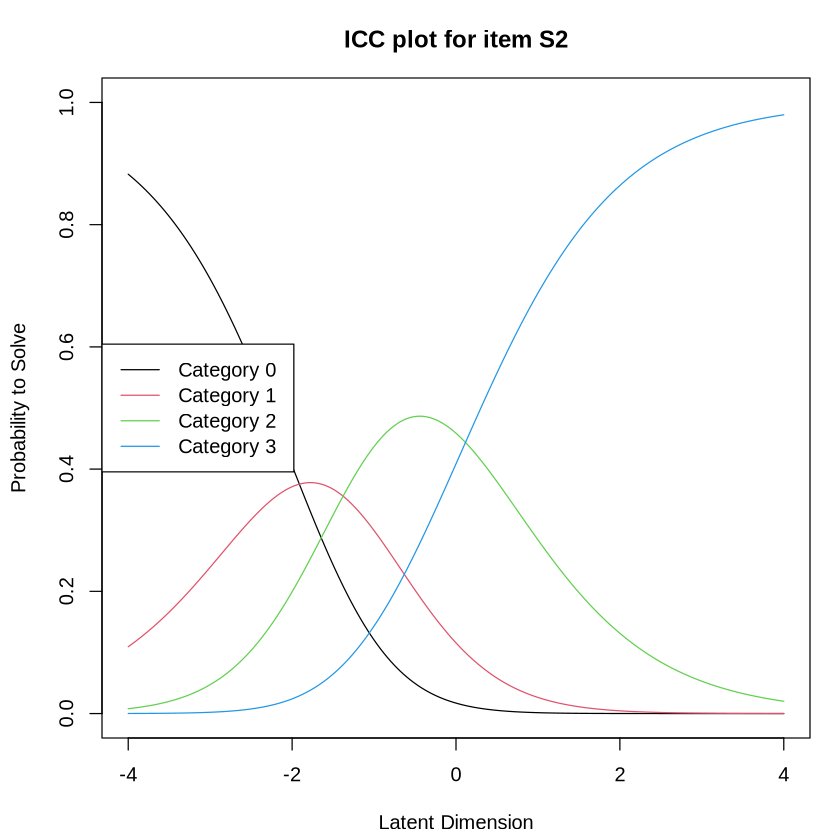

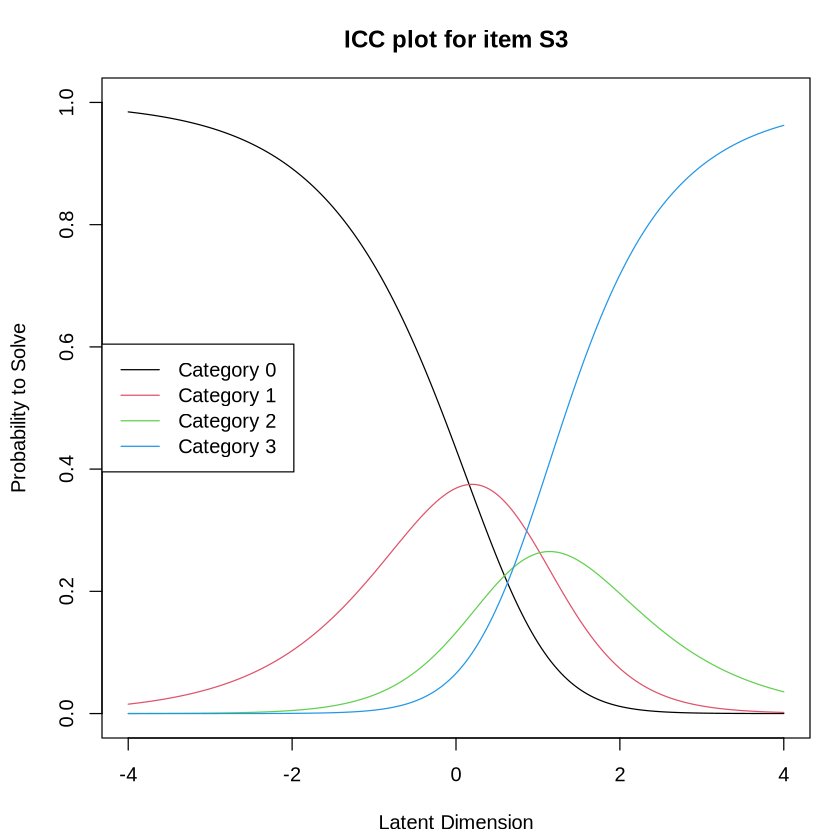

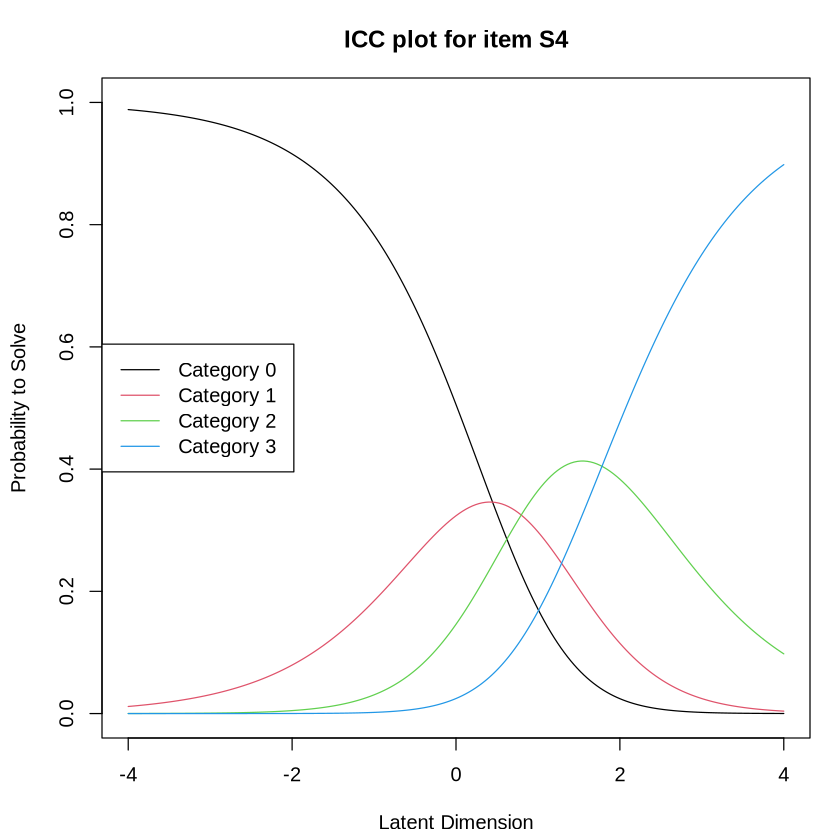

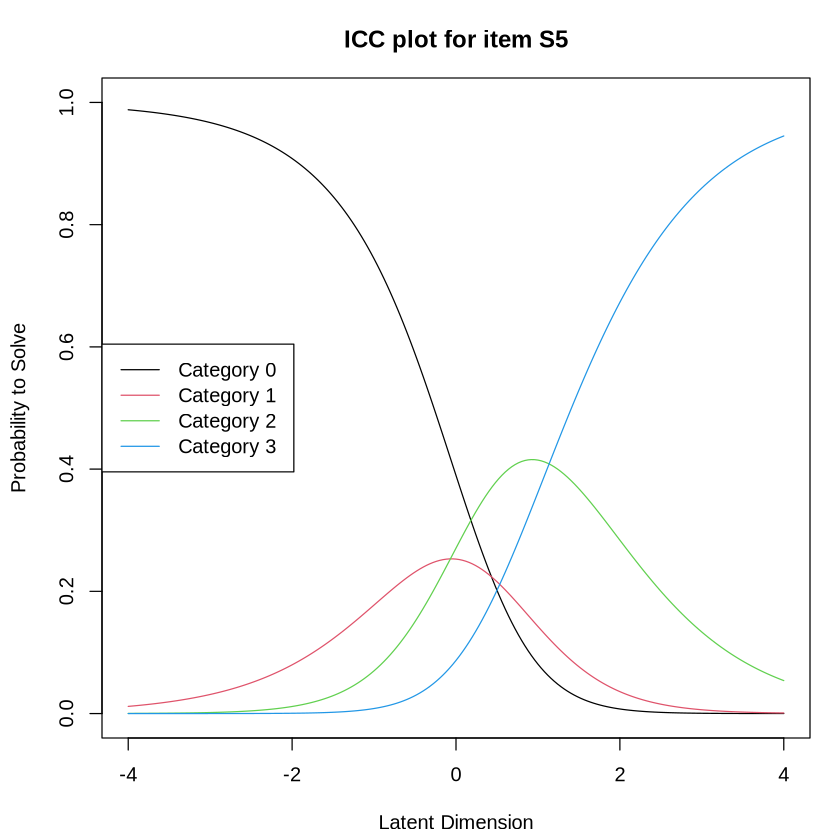

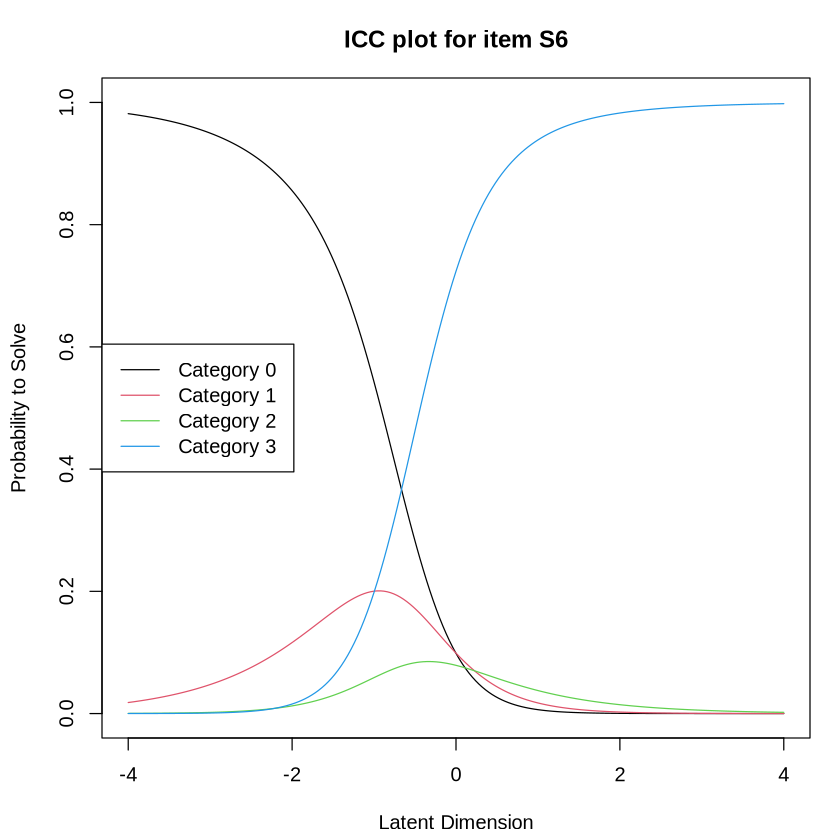

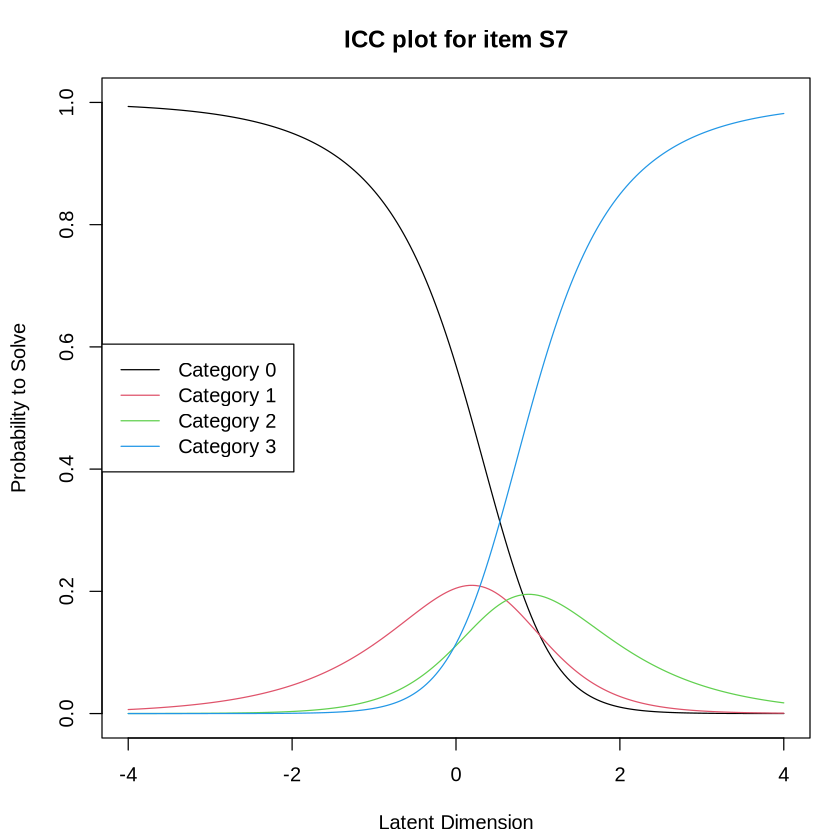

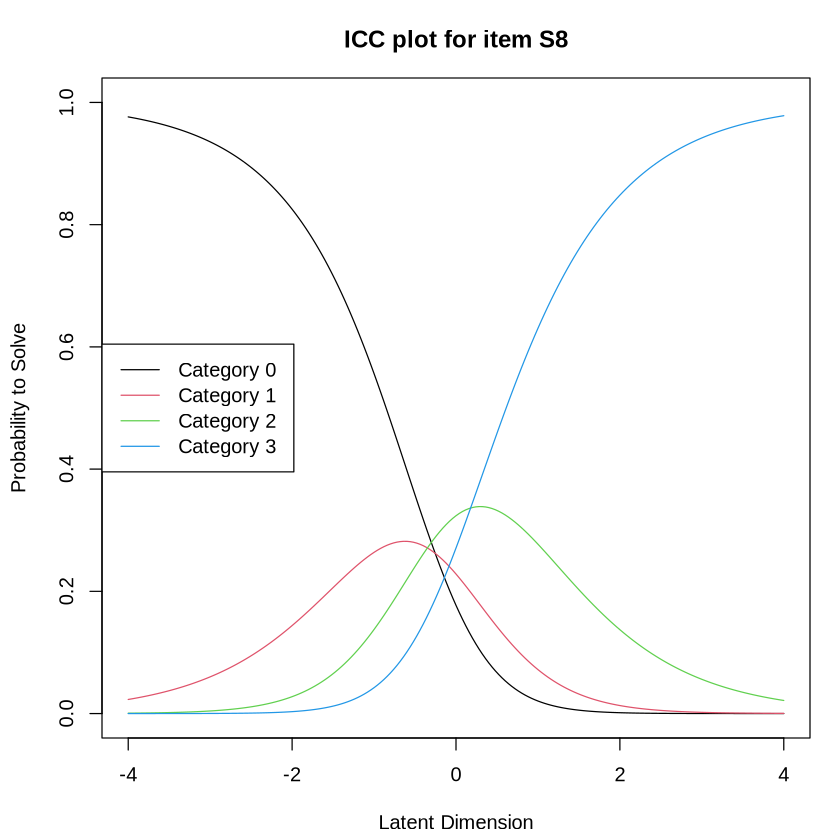

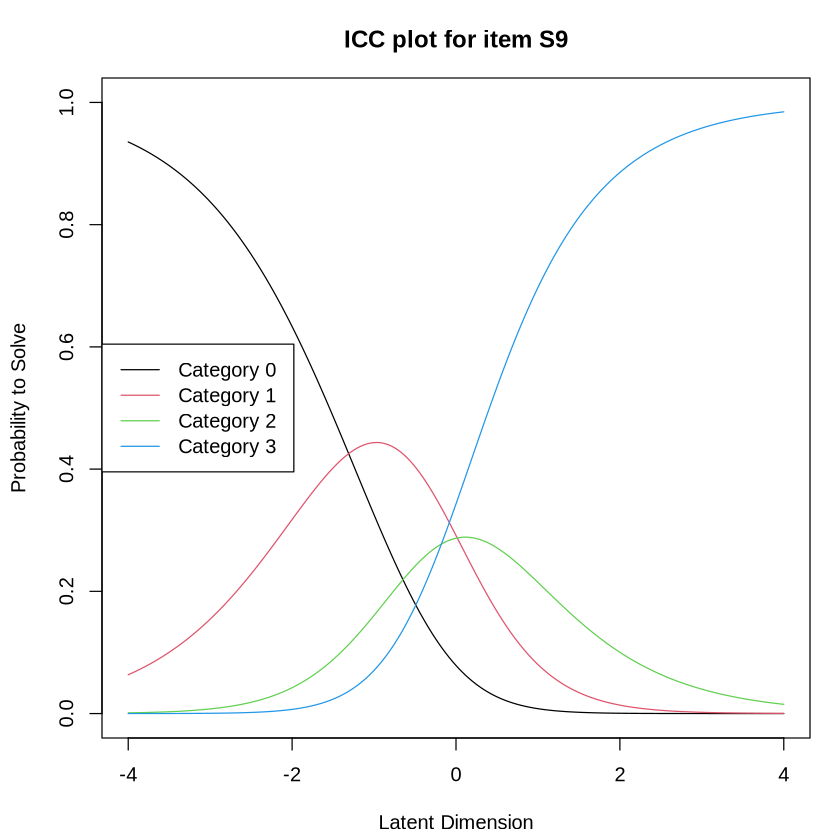

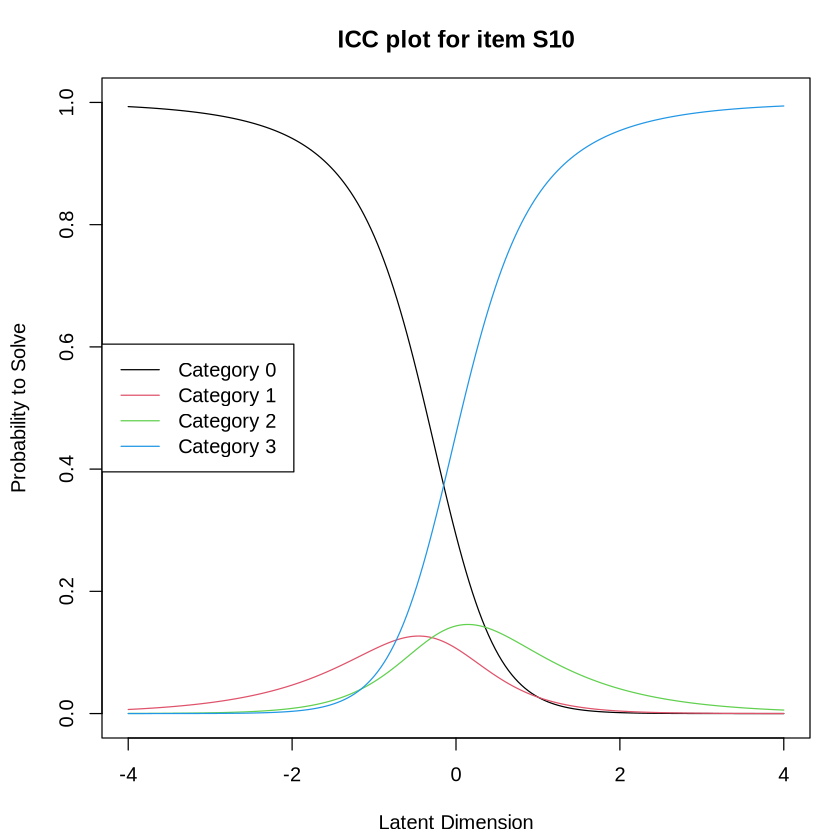

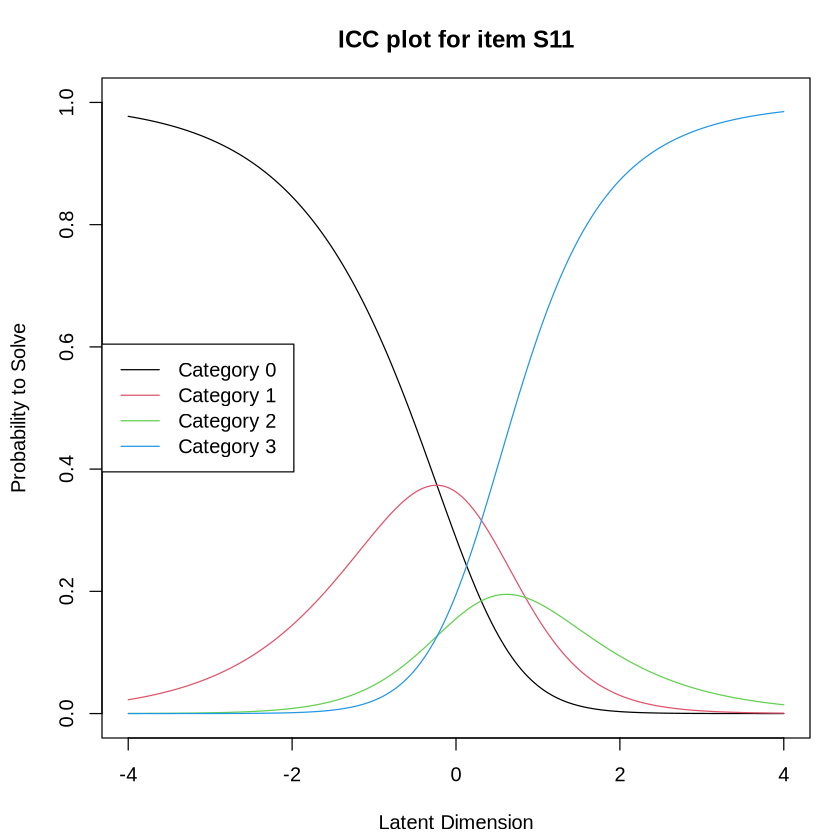

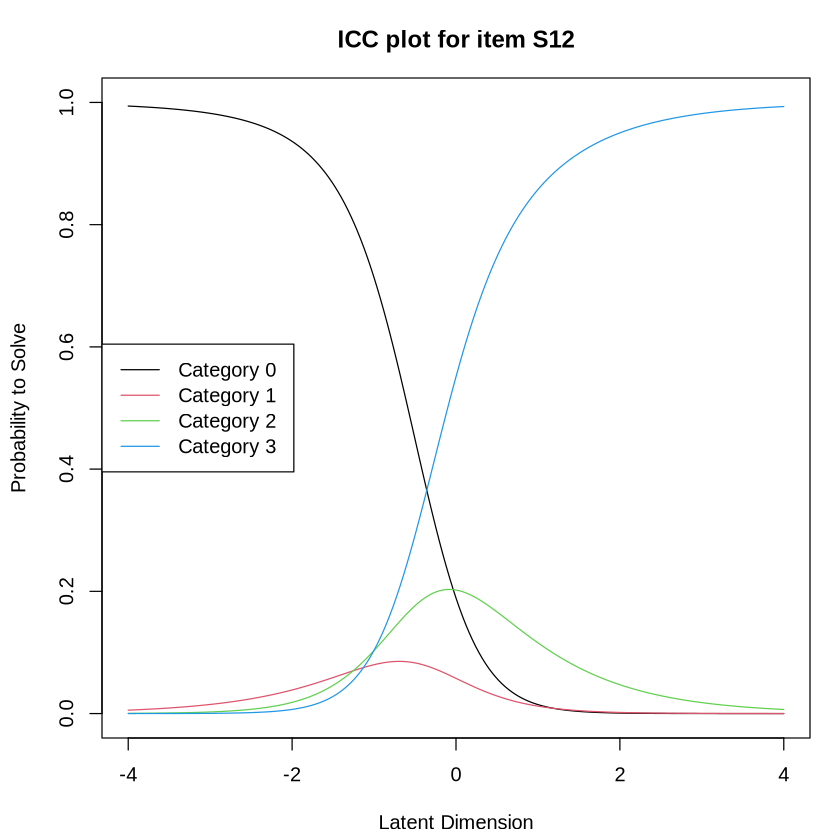

In [19]:
plotICC(rasch_model_poli)

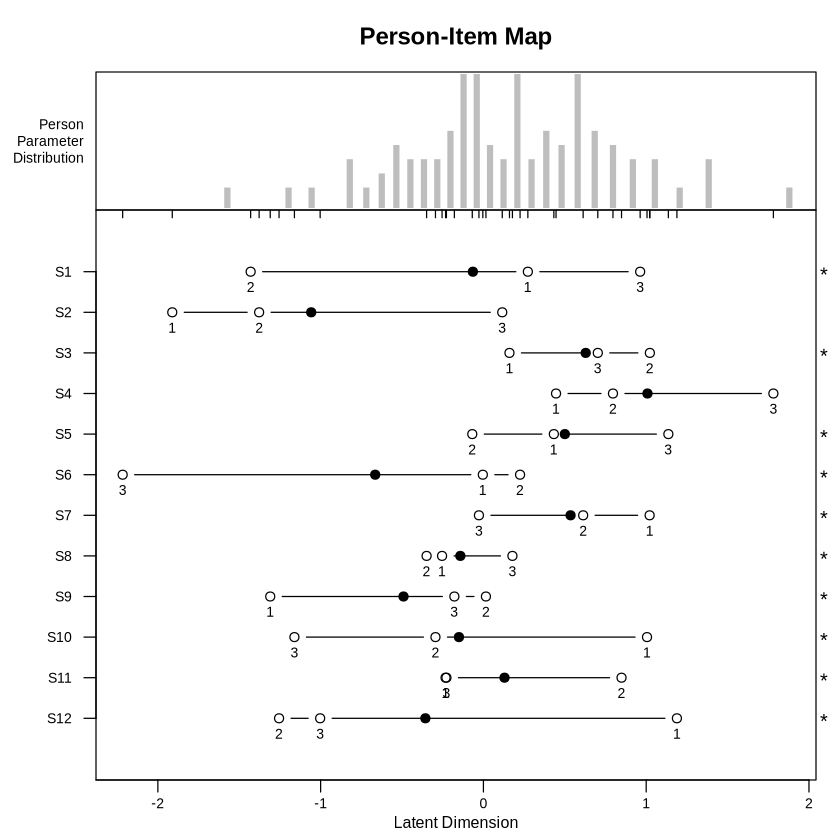

In [20]:
plotPImap(rasch_model_poli)

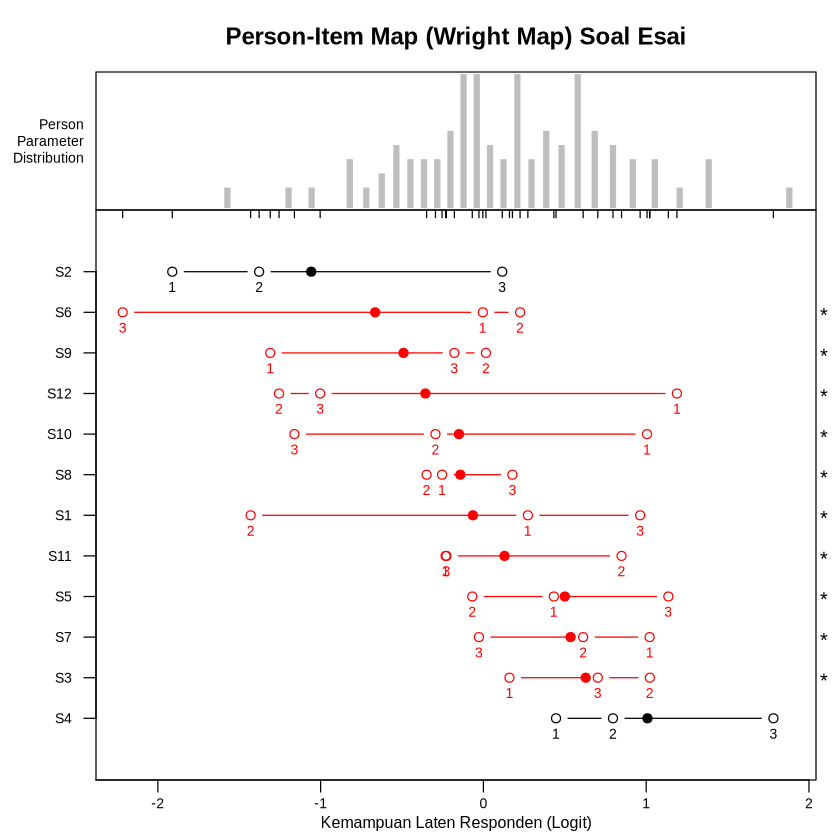

In [24]:
# Versi bersih dan aman yang didukung penuh oleh paket eRm
plotPImap(rasch_model_poli, 
          sorted = TRUE,          # Tetap mempertahankan urutan dari termudah ke tersulit
          main = "Person-Item Map (Wright Map) Soal Esai", 
          latdim = "Kemampuan Laten Responden (Logit)", 
          warn.ord = TRUE,         # Memberi penanda jika ada threshold yang disordered
          warn.ord.col = "red")    # Warna penanda untuk threshold yang bermasalah

In [34]:
th_matrix <- thresholds(rasch_model_poli)$threshtable[[1]]

# [DIAGNOSTIK] Mari kita intip nama asli kolom dari eRm
print("=== Nama Kolom Asli dari eRm ===")
print(colnames(th_matrix))

[1] "=== Nama Kolom Asli dari eRm ==="
[1] "Location"    "Threshold 1" "Threshold 2" "Threshold 3"


In [35]:
# Transformasi menggunakan selektor absolut (-Item)
df_item <- as.data.frame(th_matrix) %>%
  mutate(Item = factor(rownames(th_matrix), levels = rev(rownames(th_matrix)))) %>%
  pivot_longer(cols = -Item, names_to = "Threshold", values_to = "Logit") %>% # Perbaikan kunci di sini
  filter(!is.na(Logit))

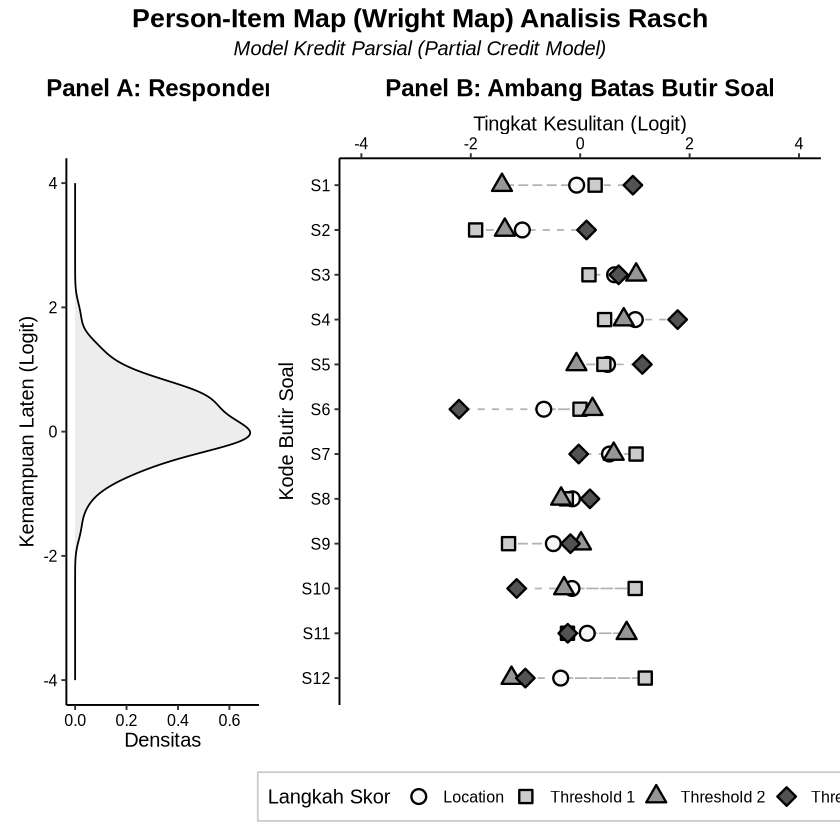

In [36]:
# 5. PANEL B: Peta Struktur Ambang Batas Butir Soal (Diperbarui)
plot_item <- ggplot(df_item, aes(x = Item, y = Logit)) +
  geom_line(aes(group = Item), color = "grey70", linetype = "dashed") +
  geom_point(aes(shape = Threshold, fill = Threshold), size = 3.5, stroke = 1) +
  # KUNCI PERBAIKAN: Menyediakan 5 bentuk (21=Lingkaran, 22=Persegi, 24=Segitiga, 23=Belah Ketupat, 25=Segitiga Terbalik)
  scale_shape_manual(values = c(21, 22, 24, 23, 25)) + 
  scale_fill_brewer(palette = "Greys") + # Menambahkan kontras warna di dalam simbol
  scale_y_continuous(limits = c(-4, 4), position = "right") + 
  coord_flip() +
  labs(title = "Panel B: Ambang Batas Butir Soal", 
       x = "Kode Butir Soal", 
       y = "Tingkat Kesulitan (Logit)", 
       shape = "Langkah Skor",
       fill = "Langkah Skor") +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.text = element_text(color = "black"),
    legend.position = "bottom",
    # MEMPERBAIKI WARNING: Mengganti size menjadi linewidth
    legend.background = element_rect(color = "grey80", linewidth = 0.5) 
  )

# 6. Penggabungan Panel Menggunakan Patchwork
wright_map_q1 <- plot_person + plot_item + 
  plot_layout(widths = c(1, 2.5)) +
  plot_annotation(
    title = "Person-Item Map (Wright Map) Analisis Rasch",
    subtitle = "Model Kredit Parsial (Partial Credit Model)",
    theme = theme(
      plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
      plot.subtitle = element_text(size = 12, face = "italic", hjust = 0.5)
    )
  )

# 7. Menampilkan Grafik
print(wright_map_q1)

In [21]:
item_fit_stats <- itemfit(kemampuan_siswa)
print(item_fit_stats)


Itemfit Statistics: 
      Chisq  df p-value Outfit MSQ Infit MSQ Outfit t Infit t Discrim
S1   90.474 101   0.764      0.887     0.887   -0.786  -0.880   0.470
S2  107.054 101   0.321      1.050     1.023    0.375   0.206   0.230
S3   92.385 101   0.718      0.906     0.962   -0.637  -0.264   0.377
S4  105.658 101   0.356      1.036     0.981    0.295  -0.104   0.313
S5  122.645 101   0.070      1.202     1.080    1.582   0.739   0.268
S6   76.764 101   0.965      0.753     0.846   -0.796  -0.978   0.482
S7  125.288 101   0.051      1.228     1.226    1.325   1.803   0.169
S8   85.514 101   0.865      0.838     0.882   -1.262  -1.044   0.527
S9   86.245 101   0.852      0.846     0.881   -1.197  -1.033   0.502
S10  82.168 101   0.915      0.806     0.911   -1.022  -0.776   0.487
S11  80.415 101   0.935      0.788     0.819   -1.755  -1.730   0.565
S12  71.218 101   0.989      0.698     0.811   -1.463  -1.487   0.552



# Unidimensionality

In [22]:
# 1. Get the residuals
resids <- residuals(kemampuan_siswa)

# 2. Run PCA
pca_resids <- prcomp(resids)

# 3. Look at the Eigenvalues (The "Rule of 2.0")
# If the first eigenvalue is < 2.0, you are safe!
print(pca_resids$sdev^2)

 [1] 1.74591770 1.49830630 1.31269516 1.20490876 1.04517800 0.98717723
 [7] 0.87553129 0.83095470 0.63706857 0.54842373 0.42203440 0.02394212


In [23]:
lr_test_result <- LRtest(rasch_model_poli, splitcr = "median")
print(lr_test_result)

Warning message in LRtest.Rm(rasch_model_poli, splitcr = "median"):
“
The following items were excluded due to inappropriate response patterns within
subgroups:
S2 S6 S12

Full and subgroup models are estimated without these items!”



Andersen LR-test: 
LR-value: 31.178 
Chi-square df: 26 
p-value:  0.222 

